# 01. Brand classifier train

Обучение query→brand на silver из `artifacts/brand_clf/`.

Спец-классы: **`NO_BRAND`**, **`UNKNOWN`** (OOD).  
Договорённости: [`../preprocessing/silver_clf_readme.md`](../preprocessing/silver_clf_readme.md)  
Отчёт: [`brand_classifier.md`](./brand_classifier.md)

Сравниваем несколько sklearn-пайплайнов (TF-IDF + линейные модели), считаем:
- accuracy / F1 macro·micro·weighted  
- **F1 по каждому классу** (таблица)  
- метрики на `NO_BRAND` / `UNKNOWN`  
- false-brand rate на category-only  
- эффект reject-порогов из `inference_policy.json`


## 0. Setup

In [1]:
%matplotlib inline
import sys
import json
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name in {"brand_classifier_train", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "brand_classifier_train" else ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder

from src.data_utils import (
    ARTIFACTS_DIR,
    FIGURES_DIR,
    MODELS,
    ensure_dirs,
    apply_plot_style,
    MVIDEO_RED,
    DARK_SLATE,
    MUTED,
    save_stats,
)

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
apply_plot_style()

DATA = ARTIFACTS_DIR / "brand_clf"
FIG = FIGURES_DIR / "brand_clf"
OUT = ARTIFACTS_DIR / "brand_clf" / "train_runs"
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

LABEL_NO_BRAND = "NO_BRAND"
LABEL_UNKNOWN = "UNKNOWN"
SEED = 42
print("DATA", DATA)
print("FIG", FIG)


DATA D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf
FIG D:\Projects-26-06-2026\mvideo-ner-search\figures\brand_clf


## 1. Загрузка silver + policy

In [2]:
train = pd.read_parquet(DATA / "silver_brand_train.parquet")
val = pd.read_parquet(DATA / "silver_brand_val.parquet")
policy = json.loads((DATA / "inference_policy.json").read_text(encoding="utf-8"))
label_map = json.loads((DATA / "label_map.json").read_text(encoding="utf-8"))
stats_silver = json.loads((DATA / "silver_brand_stats.json").read_text(encoding="utf-8"))

TAU_ACCEPT = float(policy["thresholds"]["TAU_ACCEPT"])
TAU_MARGIN = float(policy["thresholds"]["TAU_MARGIN"])
TAU_NO_BRAND = float(policy["thresholds"]["TAU_NO_BRAND"])
TAU_UNKNOWN = float(policy["thresholds"]["TAU_UNKNOWN"])

print(f"train={len(train):,}  val={len(val):,}  classes={train['brand'].nunique()}")
print("specials in train:", {
    LABEL_NO_BRAND: int((train.brand == LABEL_NO_BRAND).sum()),
    LABEL_UNKNOWN: int((train.brand == LABEL_UNKNOWN).sum()),
})
print("thresholds:", policy["thresholds"])
display(train["brand"].value_counts().head(12).to_frame("train_n"))
display(train.sample(5, random_state=0)[["query_norm", "brand", "label_reason", "sample_weight", "is_category_only"]])


train=22,846  val=5,710  classes=67
specials in train: {'NO_BRAND': 4704, 'UNKNOWN': 2457}
thresholds: {'TAU_ACCEPT': 0.42, 'TAU_MARGIN': 0.08, 'TAU_NO_BRAND': 0.35, 'TAU_UNKNOWN': 0.3, 'REQUIRE_BRAND_EVIDENCE': True}


,train_n
brand,
NO_BRAND,4704
Samsung,2585
UNKNOWN,2457
Apple,2029
Xiaomi,1498
HUAWEI,1022
Haier,815
HONOR,562
LG,393


,query_norm,brand,label_reason,sample_weight,is_category_only
6481,вертикальный моющий пылесос remez,NO_BRAND,category_only,1.0,True
15722,подписка окко премиум,NO_BRAND,category_only,1.0,True
821,раска водно-дисперсионная parade краска фасадн...,UNKNOWN,ood_brand_surface,0.9,False
10985,смартфоны xiaomi 15 t,Xiaomi,alias_hint,1.0,False
12314,honor 400 lite 12 512,HONOR,alias_hint,1.0,False


## 2. X / y / weights

- `X` = `query_norm`  
- `y` = `brand` (включая NO_BRAND / UNKNOWN)  
- `sample_weight` из silver (click-confidence); для specials уже выставлены в `03`


In [3]:
Xtr = train["query_norm"].astype(str).values
ytr = train["brand"].astype(str).values
wtr = train["sample_weight"].astype(float).values

Xva = val["query_norm"].astype(str).values
yva = val["brand"].astype(str).values

classes = sorted(set(ytr) | set(yva), key=lambda x: (x in {LABEL_NO_BRAND, LABEL_UNKNOWN}, x))
print("n_classes", len(classes))
assert set(yva).issubset(set(ytr)), "val has unseen labels — пересоберите silver split"


n_classes 67


## 3. Модели

| id | Векторизация | Классификатор | Зачем |
|---|---|---|---|
| `logreg_char` | char_wb (2–4) | LogReg + sample_weight | близко к старому `07` |
| `logreg_char_bal` | char_wb (2–4) | LogReg class_weight=balanced | редкие бренды |
| `logreg_wordchar` | word(1–2) + char_wb(2–4) | LogReg + weights | алиасы + опечатки |
| `sgd_char` | char_wb (2–5) | SGD log_loss | быстрый линейный baseline |


In [ ]:
def make_pipelines(seed: int = SEED) -> dict[str, Pipeline]:
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, max_features=50_000)
    char5 = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, max_features=60_000)
    word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, max_features=25_000)
    union = FeatureUnion([("word", word), ("char", char)])
    lr_kw = dict(max_iter=200, solver="lbfgs", random_state=seed)

    return {
        "logreg_char": Pipeline([
            ("tfidf", char),
            ("clf", LogisticRegression(**lr_kw)),
        ]),
        "logreg_char_bal": Pipeline([
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, max_features=50_000)),
            ("clf", LogisticRegression(**lr_kw, class_weight="balanced")),
        ]),
        "logreg_wordchar": Pipeline([
            ("tfidf", union),
            ("clf", LogisticRegression(**lr_kw)),
        ]),
        "sgd_char": Pipeline([
            ("tfidf", char5),
            ("clf", SGDClassifier(
                loss="log_loss", penalty="l2", alpha=1e-5,
                max_iter=25, random_state=seed, tol=1e-3,
            )), # << Этот лучше всех
        ]),
    }

PIPELINES = make_pipelines()
print(list(PIPELINES))


['logreg_char', 'logreg_char_bal', 'logreg_wordchar', 'sgd_char']


## 4. Обучение + метрики

In [5]:
def proba_matrix(pipe: Pipeline, X) -> np.ndarray | None:
    clf = pipe.named_steps["clf"]
    if hasattr(clf, "predict_proba"):
        return pipe.predict_proba(X)
    return None


def apply_reject(pred: np.ndarray, proba: np.ndarray | None, class_names: list[str]) -> np.ndarray:
    """Политика inference: низкая уверенность / NO_BRAND / UNKNOWN → служебный REJECT.
    Для сравнения метрик REJECT считаем как NO_BRAND (brand=null)."""
    out = pred.astype(object).copy()
    if proba is None:
        # без вероятностей: UNKNOWN/NO_BRAND оставляем, иначе без reject
        return out
    name_to_i = {c: i for i, c in enumerate(class_names)}
    for i, p in enumerate(pred):
        row = proba[i]
        order = np.argsort(row)[::-1]
        p1 = float(row[order[0]])
        p2 = float(row[order[1]]) if len(order) > 1 else 0.0
        margin = p1 - p2
        if p == LABEL_NO_BRAND:
            out[i] = LABEL_NO_BRAND if p1 >= TAU_NO_BRAND else LABEL_NO_BRAND
            continue
        if p == LABEL_UNKNOWN:
            out[i] = LABEL_UNKNOWN if p1 >= TAU_UNKNOWN else LABEL_NO_BRAND
            continue
        if p1 >= TAU_ACCEPT and margin >= TAU_MARGIN:
            out[i] = p
        else:
            out[i] = LABEL_NO_BRAND  # reject → null
    return out


def eval_pack(y_true, y_pred, labels: list[str]) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_micro": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "report": classification_report(
            y_true, y_pred, labels=labels, output_dict=True, zero_division=0
        ),
    }


def subset_metrics(val_df: pd.DataFrame, y_pred: np.ndarray) -> dict:
    yt = val_df["brand"].astype(str).values
    # false brand: category-only, предсказали конкретный бренд
    mask_co = val_df["is_category_only"].astype(bool).values
    if mask_co.any():
        pred_co = y_pred[mask_co]
        false_brand = np.mean([
            (p not in {LABEL_NO_BRAND, LABEL_UNKNOWN}) for p in pred_co
        ])
    else:
        false_brand = None
    # NO_BRAND / UNKNOWN F1
    def _f1(label):
        return float(f1_score(yt == label, y_pred == label, zero_division=0))
    return {
        "n_category_only_val": int(mask_co.sum()),
        "false_brand_rate_category_only": false_brand,
        "f1_NO_BRAND": _f1(LABEL_NO_BRAND),
        "f1_UNKNOWN": _f1(LABEL_UNKNOWN),
        "support_NO_BRAND": int((yt == LABEL_NO_BRAND).sum()),
        "support_UNKNOWN": int((yt == LABEL_UNKNOWN).sum()),
    }


results = {}
per_class_tables = {}

for name, pipe in PIPELINES.items():
    print(f"\n=== train {name} ===")
    use_w = name != "logreg_char_bal"  # balanced уже компенсирует частоты
    if use_w:
        pipe.fit(Xtr, ytr, clf__sample_weight=wtr)
    else:
        pipe.fit(Xtr, ytr)

    pred = pipe.predict(Xva)
    proba = proba_matrix(pipe, Xva)
    class_names = list(pipe.named_steps["clf"].classes_)
    pred_rej = apply_reject(pred, proba, class_names)

    pack = eval_pack(yva, pred, classes)
    pack_rej = eval_pack(yva, pred_rej, classes)
    sub = subset_metrics(val, pred)
    sub_rej = subset_metrics(val, pred_rej)

    results[name] = {
        "raw": {k: pack[k] for k in ["accuracy", "f1_macro", "f1_micro", "f1_weighted"]},
        "reject": {k: pack_rej[k] for k in ["accuracy", "f1_macro", "f1_micro", "f1_weighted"]},
        "subset_raw": sub,
        "subset_reject": sub_rej,
        "n_params_hint": name,
    }
    # per-class table
    rep = pack["report"]
    rows = []
    for lab in classes:
        if lab not in rep:
            continue
        r = rep[lab]
        rows.append({
            "class": lab,
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1-score"],
            "support": int(r["support"]),
        })
    per_class_tables[name] = pd.DataFrame(rows).sort_values("f1")
    results[name]["per_class"] = per_class_tables[name].to_dict(orient="records")

    joblib.dump(pipe, OUT / f"{name}.joblib")
    print(
        f"  acc={pack['accuracy']:.3f}  f1_macro={pack['f1_macro']:.3f}  "
        f"f1_NO_BRAND={sub['f1_NO_BRAND']:.3f}  f1_UNKNOWN={sub['f1_UNKNOWN']:.3f}  "
        f"false_brand@cat={sub['false_brand_rate_category_only']}"
    )

summary = pd.DataFrame([
    {
        "model": n,
        **{f"raw_{k}": v["raw"][k] for k in ["accuracy", "f1_macro", "f1_micro", "f1_weighted"]},
        **{f"rej_{k}": v["reject"][k] for k in ["accuracy", "f1_macro", "f1_micro"]},
        "f1_NO_BRAND": v["subset_raw"]["f1_NO_BRAND"],
        "f1_UNKNOWN": v["subset_raw"]["f1_UNKNOWN"],
        "false_brand_cat": v["subset_raw"]["false_brand_rate_category_only"],
    }
    for n, v in results.items()
]).sort_values("raw_f1_macro", ascending=False)

display(summary.round(4))
summary.to_csv(OUT / "models_summary.csv", index=False)



=== train logreg_char ===
  acc=0.928  f1_macro=0.910  f1_NO_BRAND=0.848  f1_UNKNOWN=0.828  false_brand@cat=0.07908163265306123

=== train logreg_char_bal ===
  acc=0.921  f1_macro=0.936  f1_NO_BRAND=0.806  f1_UNKNOWN=0.801  false_brand@cat=0.16666666666666666

=== train logreg_wordchar ===
  acc=0.944  f1_macro=0.950  f1_NO_BRAND=0.878  f1_UNKNOWN=0.856  false_brand@cat=0.06887755102040816

=== train sgd_char ===
  acc=0.944  f1_macro=0.951  f1_NO_BRAND=0.875  f1_UNKNOWN=0.856  false_brand@cat=0.0935374149659864


,model,raw_accuracy,raw_f1_macro,raw_f1_micro,raw_f1_weighted,rej_accuracy,rej_f1_macro,rej_f1_micro,f1_NO_BRAND,f1_UNKNOWN,false_brand_cat
3,sgd_char,0.9436,0.9506,0.9436,0.9430,0.9438,0.9488,0.9438,0.8754,0.8556,0.0935
2,logreg_wordchar,0.9441,0.9495,0.9441,0.9438,0.9361,0.9308,0.9361,0.8784,0.8564,0.0689
1,logreg_char_bal,0.9214,0.9359,0.9214,0.9194,0.8601,0.9254,0.8601,0.8061,0.8013,0.1667
0,logreg_char,0.9277,0.9103,0.9277,0.9272,0.9140,0.8656,0.9140,0.8483,0.8279,0.0791


## 5. Per-class F1 (лучший по macro-F1)

In [30]:
best_name = summary.iloc[0]["model"]
print("BEST:", best_name)
best_tbl = per_class_tables[best_name].copy()
best_tbl["is_special"] = best_tbl["class"].isin([LABEL_NO_BRAND, LABEL_UNKNOWN])
display(best_tbl.sort_values("f1", ascending=False).head(20).round(3))
print("\nХудшие классы по F1:")
display(best_tbl.sort_values("f1").head(20).round(3))

# сохранить все per-class
for n, tbl in per_class_tables.items():
    tbl.to_csv(OUT / f"per_class_f1__{n}.csv", index=False)

best_tbl.to_csv(OUT / "per_class_f1__BEST.csv", index=False)


BEST: sgd_char


,class,precision,recall,f1,support,is_special
5,BQ,1.000,1.0,1.000,6,False
0,ASUS,1.000,1.0,1.000,77,False
26,HUAWEI,1.000,1.0,1.000,255,False
31,Infinix,1.000,1.0,1.000,23,False
24,Grundig,1.000,1.0,1.000,7,False
25,HONOR,1.000,1.0,1.000,141,False
40,MSI,1.000,1.0,1.000,32,False
35,Kitfort,1.000,1.0,1.000,40,False
44,Oasis,1.000,1.0,1.000,4,False
45,Pantum,1.000,1.0,1.000,10,False



Худшие классы по F1:


,class,precision,recall,f1,support,is_special
47,PlayStation,1.000,0.500,0.667,4,False
15,Centek,0.833,0.833,0.833,12,False
66,UNKNOWN,0.938,0.787,0.856,614,True
21,Electrolux,0.818,0.900,0.857,20,False
65,NO_BRAND,0.864,0.887,0.875,1176,True
36,Krona,0.857,0.923,0.889,13,False
8,Beko,0.868,0.917,0.892,36,False
28,Hi,1.000,0.810,0.895,21,False
12,Candy,0.857,0.938,0.896,32,False
22,Gefest,0.880,0.917,0.898,24,False


## 6. Confusion / ошибки на спец-классах

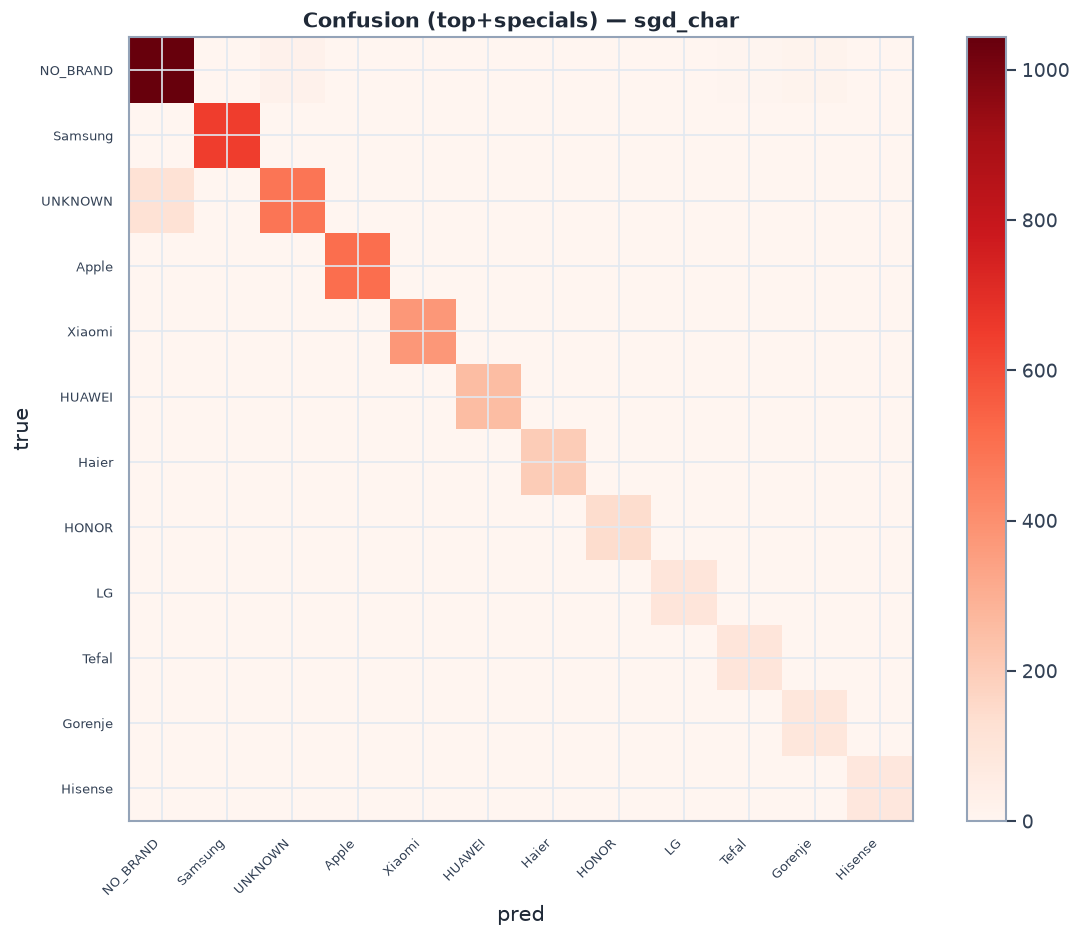

errors: 322 / 5,710 (5.6%)

NO_BRAND → wrongly predicted as brand:


,n
pred,
UNKNOWN,23
Gorenje,14
Bosch,9
Tefal,6
DeLonghi,5
Midea,5
Kuppersberg,4
Beko,4
Apple,4



True brand → predicted NO_BRAND / UNKNOWN:


,,n
brand,pred,
UNKNOWN,NO_BRAND,116
NO_BRAND,UNKNOWN,23
Philips,NO_BRAND,4
Dreame,NO_BRAND,4
Hi,NO_BRAND,3
LG,NO_BRAND,3
Tefal,NO_BRAND,3
Midea,NO_BRAND,2
Gorenje,NO_BRAND,2



sample errors:


,query_norm,brand,pred,pred_reject,label_reason,is_category_only
4710,духовой шкаф indesit,NO_BRAND,Indesit,Indesit,category_only,True
3071,холодильники двухкамерные midea nofrost,Midea,NO_BRAND,NO_BRAND,brand_in_query,False
2948,стиральная машинка. lg,NO_BRAND,LG,LG,category_only,True
4460,экшн камера sjcam sj8 pro,UNKNOWN,NO_BRAND,NO_BRAND,ood_brand_surface,False
2831,робот мойщик окон hobot 388,UNKNOWN,NO_BRAND,NO_BRAND,ood_brand_surface,False
3063,капсульная кофемашина delonghi,NO_BRAND,DeLonghi,DeLonghi,category_only,True
1307,паровой очиститель karcher,NO_BRAND,Karcher,Karcher,category_only,True
2996,электрический духовой шкаф bosch,NO_BRAND,Bosch,Bosch,category_only,True
2171,оверлок,NO_BRAND,UNKNOWN,UNKNOWN,category_only,True
4112,посудомоечная машина electrolux edm23101 l,UNKNOWN,Electrolux,Electrolux,ood_brand_surface,False


In [7]:
best_pipe = joblib.load(OUT / f"{best_name}.joblib")
pred_best = best_pipe.predict(Xva)
proba_best = proba_matrix(best_pipe, Xva)
pred_best_rej = apply_reject(pred_best, proba_best, list(best_pipe.named_steps["clf"].classes_))

# top brands + specials for CM
top_show = (
    list(pd.Series(yva).value_counts().head(12).index)
)
# ensure specials
for s in (LABEL_NO_BRAND, LABEL_UNKNOWN):
    if s not in top_show:
        top_show.append(s)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(yva, pred_best, labels=top_show)
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks(range(len(top_show)))
ax.set_yticks(range(len(top_show)))
ax.set_xticklabels(top_show, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(top_show, fontsize=8)
ax.set_xlabel("pred")
ax.set_ylabel("true")
ax.set_title(f"Confusion (top+specials) — {best_name}")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG / "01_confusion_best.png", dpi=140, bbox_inches="tight")
plt.show()

# error gallery
err = val.copy()
err["pred"] = pred_best
err["pred_reject"] = pred_best_rej
err_bad = err[err["brand"] != err["pred"]]
print(f"errors: {len(err_bad):,} / {len(err):,} ({len(err_bad)/len(err):.1%})")

print("\nNO_BRAND → wrongly predicted as brand:")
display(
    err_bad[err_bad["brand"] == LABEL_NO_BRAND]
    .groupby("pred").size().sort_values(ascending=False).head(10).to_frame("n")
)
print("\nTrue brand → predicted NO_BRAND / UNKNOWN:")
miss = err_bad[err_bad["pred"].isin([LABEL_NO_BRAND, LABEL_UNKNOWN])]
display(miss.groupby(["brand", "pred"]).size().sort_values(ascending=False).head(15).to_frame("n"))

print("\nsample errors:")
display(err_bad.sample(min(12, len(err_bad)), random_state=1)[
    ["query_norm", "brand", "pred", "pred_reject", "label_reason", "is_category_only"]
])
err_bad.head(500).to_csv(OUT / "errors_sample.csv", index=False)


## 7. Сравнение raw vs reject-policy

,model,raw_accuracy,raw_f1_macro,rej_accuracy,rej_f1_macro,f1_NO_BRAND,f1_UNKNOWN,false_brand_cat
3,sgd_char,0.9436,0.9506,0.9438,0.9488,0.8754,0.8556,0.0935
2,logreg_wordchar,0.9441,0.9495,0.9361,0.9308,0.8784,0.8564,0.0689
1,logreg_char_bal,0.9214,0.9359,0.8601,0.9254,0.8061,0.8013,0.1667
0,logreg_char,0.9277,0.9103,0.9140,0.8656,0.8483,0.8279,0.0791


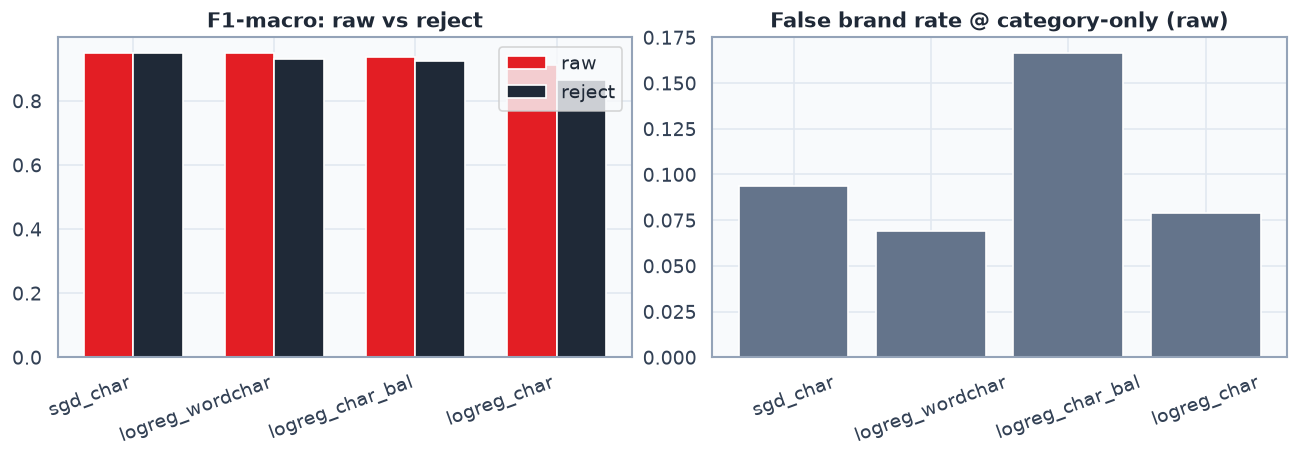

In [8]:
cmp = summary[["model", "raw_accuracy", "raw_f1_macro", "rej_accuracy", "rej_f1_macro",
               "f1_NO_BRAND", "f1_UNKNOWN", "false_brand_cat"]].copy()
display(cmp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(summary))
w = 0.35
axes[0].bar(x - w/2, summary["raw_f1_macro"], w, label="raw", color=MVIDEO_RED)
axes[0].bar(x + w/2, summary["rej_f1_macro"], w, label="reject", color=DARK_SLATE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary["model"], rotation=20, ha="right")
axes[0].set_title("F1-macro: raw vs reject")
axes[0].legend()

axes[1].bar(summary["model"], summary["false_brand_cat"].fillna(0), color=MUTED)
axes[1].set_title("False brand rate @ category-only (raw)")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG / "02_models_compare.png", dpi=140, bbox_inches="tight")
plt.show()


## 8. Сохранение лучшей модели + metrics.json

In [9]:
# финальный артефакт для сервиса / 07-замены
best_pipe = joblib.load(OUT / f"{best_name}.joblib")
joblib.dump(best_pipe, MODELS / "brand_clf.joblib")
joblib.dump(best_pipe, MODELS / f"brand_clf__{best_name}.joblib")

metrics_out = {
    "best_model": best_name,
    "n_train": int(len(train)),
    "n_val": int(len(val)),
    "n_classes": int(len(classes)),
    "thresholds": policy["thresholds"],
    "summary": summary.to_dict(orient="records"),
    "best_raw": results[best_name]["raw"],
    "best_reject": results[best_name]["reject"],
    "best_subset_raw": results[best_name]["subset_raw"],
    "best_subset_reject": results[best_name]["subset_reject"],
    "worst_classes": best_tbl.sort_values("f1").head(15).to_dict(orient="records"),
    "best_classes": best_tbl.sort_values("f1", ascending=False).head(15).to_dict(orient="records"),
    "silver_stats_ref": {
        "no_brand_share": stats_silver.get("no_brand_share"),
        "unknown_share": stats_silver.get("unknown_share"),
    },
}
save_stats(metrics_out, OUT / "metrics.json")
save_stats(metrics_out, DATA / "train_metrics.json")
print("saved model →", MODELS / "brand_clf.joblib")
print("saved metrics →", OUT / "metrics.json")
print(json.dumps({k: metrics_out[k] for k in ["best_model", "best_raw", "best_subset_raw"]}, indent=2, ensure_ascii=False))


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf\train_runs\metrics.json
Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf\train_metrics.json
saved model → D:\Projects-26-06-2026\mvideo-ner-search\models\brand_clf.joblib
saved metrics → D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf\train_runs\metrics.json
{
  "best_model": "sgd_char",
  "best_raw": {
    "accuracy": 0.9436077057793345,
    "f1_macro": 0.9505720828901706,
    "f1_micro": 0.9436077057793345,
    "f1_weighted": 0.9430452449901036
  },
  "best_subset_raw": {
    "n_category_only_val": 1176,
    "false_brand_rate_category_only": 0.0935374149659864,
    "f1_NO_BRAND": 0.8753671842215694,
    "f1_UNKNOWN": 0.8556244464127547,
    "support_NO_BRAND": 1176,
    "support_UNKNOWN": 614
  }
}


## 9. Выводы (заполнить после Run All)

Смотри авто-отчёт [`brand_classifier.md`](./brand_classifier.md) — он обновляется скриптом `_run_01.py` / по цифрам из `train_runs/metrics.json`.

Краткий чеклист:
- [ ] macro-F1 лучше старого ~0.67?  
- [ ] `false_brand_rate` на category-only низкий?  
- [ ] F1(`NO_BRAND`) / F1(`UNKNOWN`) приемлемы?  
- [ ] хвост классов с F1≈0 — поднять support / объединить / оставить UNKNOWN  


In [29]:
from notebooks.brand_classifier_train.predict_brand import predict_brand
# или из корня репо:
# python notebooks/brand_classifier_train/predict_brand.py

predict_brand("Andesit 15", return_proba=True)                      # -> "Apple"
# predict_brand("холодильник афон", return_proba=True)  # -> ("NO_BRAND", {...})

('Indesit',
 {'Indesit': 0.3998953895356654,
  'UNKNOWN': 0.17874679518345335,
  'Apple': 0.09026249599770837,
  'Xiaomi': 0.03663149472274901,
  'NO_BRAND': 0.029553715845047752,
  'MSI': 0.012607392463214222,
  'HUAWEI': 0.011748342380134084,
  'ASUS': 0.011132357204137786})

Вопросы для рисёрча:

- Возможно ли сделать модель инвариантной к опечаткам, искажениям, и пр.
- Переобучилась ли моделька (мы наблюдаем очень много 1.00 на f1 для разных классов - может быть проблема)
- Нужно ли добавлять валидацию (k-fold cross validation)
- В целом проанализировать насколько это хорошая и стабильная модель (ROC-AUC, etc.)

Задачи:

- Проверить на Gold-сете (пока что его нет)